In [45]:
import sys
sys.path.append("/Users/avelezxerenity/Documents/GitHub/pysdk")
import os
from inflation_query.Inflation_query import implied_inflation_calc
from src.xerenity.xty import Xerenity
from utilities.date_functions import add_months
from swap_functions.ibr_quantlib_details import ibr_quantlib_det,ibr_overnight_index,ibr_swap_cupon_helper,depo_helpers_ibr
import pandas as pd
import QuantLib as ql
from datetime import datetime,date
xty = Xerenity(
    username=os.getenv('XTY_USER'),
    password=os.getenv('XTY_PWD'),
)
#calc_date = ql.Date(2, 11, 2023)
#ql.Settings.instance().evaluationDate = calc_date

2023-11-03 16:25:17,868:INFO - HTTP Request: POST https://tvpehjbqxpiswkqszwwv.supabase.co/auth/v1/token?grant_type=password "HTTP/1.1 200 OK"


In [46]:
ibr_on=xty.BanRep().get_econ_data_last(id_serie=19).data[0]['valor']/100
# ibr_3m=xty.BanRep().get_econ_data_last(id_serie=13).data[0]['valor']/100
# ibr_6m=xty.BanRep().get_econ_data_last(id_serie=14).data[0]['valor']/100
# ibr_12m=xty.BanRep().get_econ_data_last(id_serie=12).data[0]['valor']/100
# ibr_depo_rates={'ibr_on':ibr_on,'ibr_3m':ibr_3m,'ibr_6m':ibr_6m,'ibr_12m':ibr_12m}
# ibr_depo_periods={'ibr_on':ql.Period('1d'),'ibr_3m':ql.Period('3m'),'ibr_6m':ql.Period('6m'),'ibr_12m':ql.Period('1y')}

2023-11-03 16:25:18,254:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/banrep_serie_value?select=%2A&id_serie=eq.19&order=fecha.desc&limit=1 "HTTP/1.1 200 OK"


In [47]:
ibr_on

0.1225

In [48]:
today=date.today()
init_date=datetime(2023, 11, 2).date()
final_date=init_date
ibr_data=pd.DataFrame(xty.get_date_range(table_name='ibr_swaps_cluster',date_column_name='execution_timestamp').data)
ibr_data['execution_timestamp'] = pd.to_datetime(ibr_data['execution_timestamp']).dt.date
mask = (ibr_data['execution_timestamp'] >= init_date) & (ibr_data['execution_timestamp'] <= final_date) & (ibr_data['action_type'] == 'NEWT')
ibr_data = ibr_data[mask] 
ibr_data= ibr_data[abs(ibr_data['days_diff_trade_effe']) < 7]
ibr_cluster_mean = pd.DataFrame(ibr_data.groupby('month_diff_effective_expiration')['rate'].mean())
ibr_cluster_mean.to_clipboard()

2023-11-03 16:25:18,488:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/ibr_swaps_cluster?select=%2A "HTTP/1.1 200 OK"
/Users/avelezxerenity/Documents/GitHub/pysdk/src/xerenity/xty.py:133: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column])
/Users/avelezxerenity/Documents/GitHub/pysdk/src/xerenity/xty.py:133: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[column] = pd.to_datetime(df[column])
2023-11-03 16:25:19,515:INFO - HTTP Request: GET https://tvpehjbqxpiswkqszwwv.supabase.co/rest/v1/ibr_swaps_cluster?select=%2A "HTTP/1.1 200 OK"


In [49]:

ibr_cluster_mean

,rate
month_diff_effective_expiration,
3,0.122967
6,0.121900
9,0.119867
12,0.115941
18,0.109125
24,0.096366
36,0.090083
60,0.085927
120,0.087186


In [50]:
OIS_helpers = []
for row in ibr_cluster_mean.iterrows():

    if row[0]<=18:
        OIS_helpers.append(depo_helpers_ibr(row[1][0],row[0],ql.Months))

    else:
        OIS_helpers.append( ibr_swap_cupon_helper(row[1][0],int(row[0]/12),ql.Years))
        print(row[1][0])
        print(int(row[0]/12))
OIS_helpers.append(depo_helpers_ibr(ibr_on,8,ql.Days))       

0.0963657
2
0.09008333333333333
3
0.08592727272727273
5
0.08718571428571428
10


/var/folders/t7/tjpkwm2d28sb_3ctgfhx6gr00000gp/T/ipykernel_98036/3857997742.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  OIS_helpers.append(depo_helpers_ibr(row[1][0],row[0],ql.Months))
/var/folders/t7/tjpkwm2d28sb_3ctgfhx6gr00000gp/T/ipykernel_98036/3857997742.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  OIS_helpers.append( ibr_swap_cupon_helper(row[1][0],int(row[0]/12),ql.Years))
/var/folders/t7/tjpkwm2d28sb_3ctgfhx6gr00000gp/T/ipykernel_98036/3857997742.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels 

In [77]:
settlement_day=ql.Date.todaysDate()+ql.Period(5,ql.Days)
print(settlement_day)
ql.Settings.instance().evaluationDate = settlement_day
#curve = ql.PiecewiseLinearZero(0, ibr_quantlib_det['calendar'], OIS_helpers, ql.Actual360())
curve =ql.PiecewiseSplineCubicDiscount(0, ibr_quantlib_det['calendar'], OIS_helpers, ql.Actual360())
#curve_ff = ql.FlatForward(0, ibr_quantlib_det['calendar'], OIS_helpers, ql.Actual360(), ql.Linear())
#curve = ql.Log(ql.NullCalendar(), OIS_helpers, ql.Actual360())



November 8th, 2023


In [78]:
ql.Thirty360(ql.Thirty360.USA)

<QuantLib.QuantLib.Thirty360; proxy of <Swig Object of type 'QuantLib::Thirty360 *' at 0x13f6116e0> >

In [79]:
date_test=ql.Date(23,11,2024)

In [80]:
curve.zeroRate(date_test,ql.Actual365Fixed(),ql.Compounded,ql.Annual).rate()

0.11689837552007765

In [83]:
import QuantLib as ql

# Assuming you already have your yield curve stored in the 'curve' variable

# Set the evaluation date
start_date = ql.Date(15, 12, 2023)


# Define the forward rate tenor
forward_tenor_1m = ql.Period(1, ql.Months)
forward_tenor_1y = ql.Period(1, ql.Years)

# Initialize lists to store results
dates = []
forward_rates = []
# Loop through 1-year steps up to 10 years (120 months)
for i in range(0, 119):
    try:
        # Calculate the forward rate for the current step
        first_date = start_date + ql.Period(i, ql.Months)
        end_date = first_date + ql.Period(3, ql.Months)
        forward_rate = curve.forwardRate(first_date, end_date, ql.Actual360(), ql.Compounded).rate()
        dates.append(first_date)
        forward_rates.append(forward_rate)
        # Print the result
        print(f"1-month {i/12} year forward rate: {forward_rate:.4%}")
    except:
        print('tenor to calculate not un curve helper')
df = pd.DataFrame(list(zip(dates, forward_rates)), columns=['Maturity Date', 'n-Month,3-month fwd rate'])

1-month 0.0 year forward rate: 12.6733%
1-month 0.08333333333333333 year forward rate: 12.4394%
1-month 0.16666666666666666 year forward rate: 12.1971%
1-month 0.25 year forward rate: 11.9619%
1-month 0.3333333333333333 year forward rate: 11.6847%
1-month 0.4166666666666667 year forward rate: 11.3152%
1-month 0.5 year forward rate: 10.8273%
1-month 0.5833333333333334 year forward rate: 10.3174%
1-month 0.6666666666666666 year forward rate: 9.8429%
1-month 0.75 year forward rate: 9.4890%
1-month 0.8333333333333334 year forward rate: 9.2228%
1-month 0.9166666666666666 year forward rate: 8.9942%
1-month 1.0 year forward rate: 8.7864%
1-month 1.0833333333333333 year forward rate: 8.5650%
1-month 1.1666666666666667 year forward rate: 8.3482%
1-month 1.25 year forward rate: 8.1428%
1-month 1.3333333333333333 year forward rate: 7.9466%
1-month 1.4166666666666667 year forward rate: 7.7815%
1-month 1.5 year forward rate: 7.6567%
1-month 1.5833333333333333 year forward rate: 7.5798%
1-month 1.66

<Axes: >

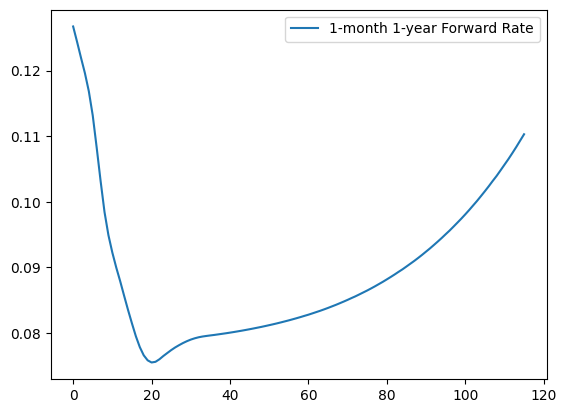

In [84]:
df.plot()